# 01 — Exploratory Data Analysis — House Price Predictor

**Input:** `data/raw/train.csv`, `data/raw/test.csv`  
**Output:** `reports/figures/eda_*.png`  
**Goal:** Understand the data before touching it.

## Questions to answer
- What's the shape and schema?
- What's missing, how much, and is it structural or random?
- What do individual distributions look like?
- Are there outliers or errors?
- How do features relate to SalePrice?
- Does train differ from test (distribution shift)?

In [2]:
import sys
sys.path.append('..')   # so we can import src and config from notebooks/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.data import load_raw_data, summarize
from config import TRAIN_FILE, TEST_FILE, TARGET, ID_COL, FIGURES_PATH

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi']     = 100
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)

In [3]:
train = load_raw_data()          # data/raw/train.csv
test  = pd.read_csv(TEST_FILE)   # data/raw/test.csv — no SalePrice column

print(f"Train: {train.shape}")
print(f"Test:  {test.shape}")

summarize(train)

INFO:src.data:Loading data from /home/victor/projects/house-price-predictor/notebooks/../data/raw/train.csv
INFO:src.data:Loaded 1,460 rows × 81 columns


Train: (1460, 81)
Test:  (1459, 80)
Shape: (1460, 81)

Dtypes:
str        43
int64      35
float64     3
Name: count, dtype: int64

Missing values (%):
PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageQual       5.547945
GarageFinish     5.547945
GarageType       5.547945
GarageYrBlt      5.547945
GarageCond       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtCond         2.534247
BsmtQual         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

Duplicates: 0


In [4]:
train.head()
train.dtypes.value_counts()
train.describe().T
train.describe(include='object').T
train.nunique().sort_values(ascending=False).head(15)

/tmp/ipykernel_7269/339782374.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  train.describe(include='object').T


Id               1460
LotArea          1073
GrLivArea         861
BsmtUnfSF         780
1stFlrSF          753
TotalBsmtSF       721
SalePrice         663
BsmtFinSF1        637
GarageArea        441
2ndFlrSF          417
MasVnrArea        327
WoodDeckSF        274
OpenPorchSF       202
BsmtFinSF2        144
EnclosedPorch     120
dtype: int64

In [5]:
missing = train.isnull().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]
print(f"{len(missing)} columns have missing values\n")
print(missing)

19 columns have missing values

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageQual       5.547945
GarageFinish     5.547945
GarageType       5.547945
GarageYrBlt      5.547945
GarageCond       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtCond         2.534247
BsmtQual         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64


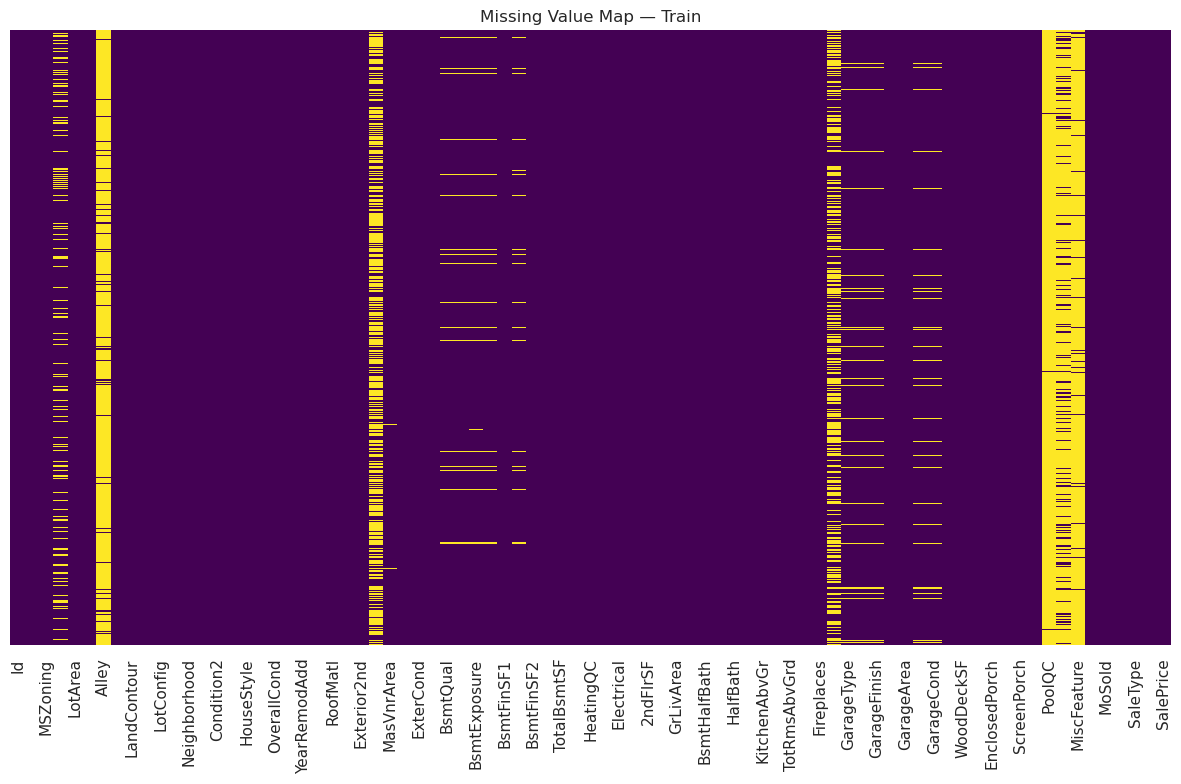

In [6]:
plt.figure(figsize=(12, 8))
sns.heatmap(train.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Value Map — Train')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'eda_missing_map.png', dpi=150, bbox_inches='tight')
plt.show()

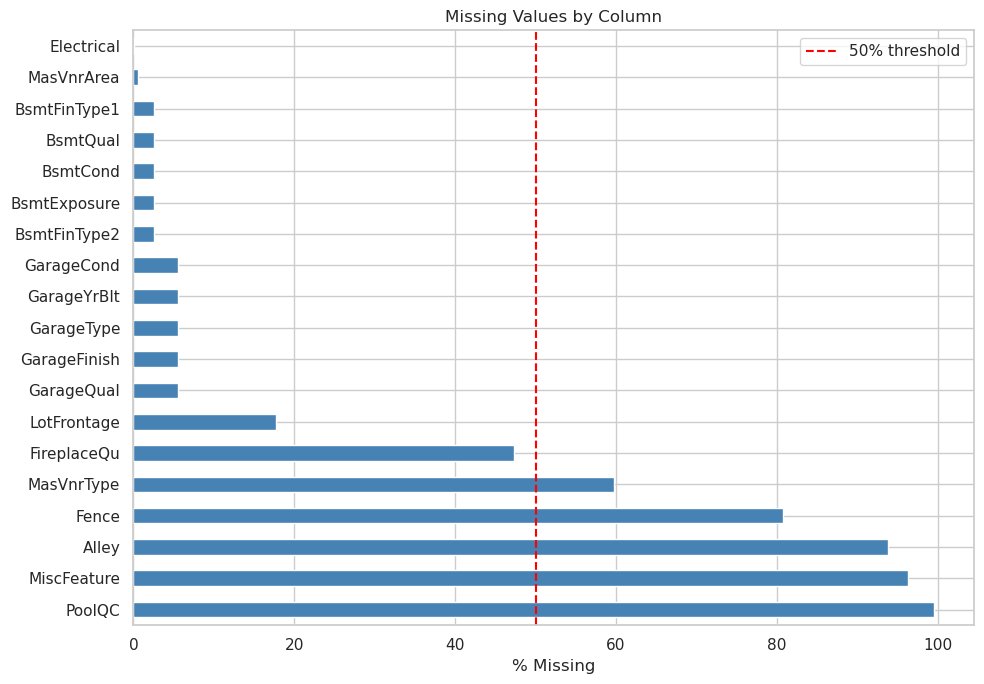

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))
missing.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('% Missing')
ax.set_title('Missing Values by Column')
ax.axvline(50, color='red', linestyle='--', label='50% threshold')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'eda_missing_bar.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:
**Cross-reference against data_description.txt:**
- `PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu`, all `Garage*`, all `Bsmt*`, `MasVnrType` → NA means the house doesn't have that feature. **Structural, not random.**
- `LotFrontage` (~18% missing) → genuinely missing, no "NA = none" meaning given. Needs real imputation.
- `Electrical` (1 missing) → genuinely missing, single row, trivial to handle.

SyntaxError: invalid character '→' (U+2192) (2320187323.py, line 2)